# 04 — Tablas finales, mapas 2D y GIF de abundancias

Este notebook genera tablas compactas y un GIF de la evolución de las abundancias. El GIF no es imprescindible para la memoria, pero puede servir para presentación.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
DATA_DIR = BASE / "data"
TAB_DIR = BASE / "tables"
GIF_DIR = BASE / "gifs"
for d in [FIG_DIR, DATA_DIR, TAB_DIR, GIF_DIR]:
    d.mkdir(exist_ok=True)

model = pd.read_csv(DATA_DIR / "bbn_evolution_t0_50s.csv")
all_models = pd.read_csv(DATA_DIR / "bbn_evolution_all_models.csv")
snapshots = pd.read_csv(DATA_DIR / "bbn_snapshots_all_models.csv")
finals = pd.read_csv(DATA_DIR / "bbn_final_compact.csv")
obs = pd.read_csv(DATA_DIR / "observational_abundances.csv")
comparison = pd.read_csv(DATA_DIR / "comparison_models_vs_observed.csv")

In [2]:
# Formato compacto para tablas de la memoria.

def fmt_sci(x, sig=3):
    if pd.isna(x):
        return ""
    x = float(x)
    if x == 0:
        return "0"
    return f"{x:.{sig}e}"

def fmt_num(x, nd=4):
    if pd.isna(x):
        return ""
    return f"{float(x):.{nd}g}"

def fmt_fixed(x, nd=6):
    if pd.isna(x):
        return ""
    return f"{float(x):.{nd}f}"

cols_model = ["model", "t0_s", "t_s", "T9", "rho_g_cm3", "eta10", "D/H", "He3/H", "X_He4", "Li7/H", "Be7/H", "Li7_plus_Be7_over_H", "baryon_sum"]

def pretty_model_table(tab):
    out = tab[cols_model].copy()
    for c in ["t0_s", "t_s"]:
        out[c] = out[c].map(lambda x: f"{float(x):.0f}")
    out["T9"] = out["T9"].map(lambda x: fmt_num(x, 3))
    out["rho_g_cm3"] = out["rho_g_cm3"].map(lambda x: fmt_sci(x, 2))
    out["eta10"] = out["eta10"].map(lambda x: fmt_num(x, 4))
    for c in ["D/H", "He3/H", "Li7/H", "Be7/H", "Li7_plus_Be7_over_H"]:
        out[c] = out[c].map(lambda x: fmt_sci(x, 3))
    out["X_He4"] = out["X_He4"].map(lambda x: fmt_fixed(x, 6))
    out["baryon_sum"] = out["baryon_sum"].map(lambda x: fmt_fixed(x, 6))
    return out

# Tabla de snapshots para Typst/LaTeX/CSV.
snap_compact = pretty_model_table(snapshots)
snap_compact.to_csv(TAB_DIR / "table_snapshots_models.csv", index=False)
snap_compact.to_latex(TAB_DIR / "table_snapshots_models.tex", index=False, escape=False)
snap_compact


,model,t0_s,t_s,T9,rho_g_cm3,eta10,D/H,He3/H,X_He4,Li7/H,Be7/H,Li7_plus_Be7_over_H,baryon_sum
0,pynucastro,50,50,1.7,2.00e-04,12.09,1.143e-27,2.402e-55,0.000000,0,0,0,1.000000
1,pynucastro,50,200,1,2.00e-05,5.939,2.725e-08,5.280e-06,0.249888,4.404e-16,8.824e-08,8.824e-08,1.000000
2,pynucastro,50,1000,0.4,2.00e-06,9.28,5.586e-09,5.263e-06,0.249888,4.702e-17,9.465e-08,9.465e-08,1.000000


In [3]:
# Tabla final para Typst/LaTeX/CSV.
final_compact = pretty_model_table(finals)
final_compact.to_csv(TAB_DIR / "table_final_models.csv", index=False)
final_compact.to_latex(TAB_DIR / "table_final_models.tex", index=False, escape=False)
final_compact


,model,t0_s,t_s,T9,rho_g_cm3,eta10,D/H,He3/H,X_He4,Li7/H,Be7/H,Li7_plus_Be7_over_H,baryon_sum
0,pynucastro,50,1000,0.4,2.00e-06,9.28,5.586e-09,5.263e-06,0.249888,4.702e-17,9.465e-08,9.465e-08,1.000000


In [4]:
# Tabla comparativa observacional: modelo vs observación.
comparison_pretty = comparison.copy()

def fmt_compare(row):
    if row["observable"] == "Yp_He4":
        return fmt_fixed(row["value"], 6)
    return fmt_sci(row["value"], 3)

comparison_pretty["value"] = comparison_pretty.apply(fmt_compare, axis=1)
comparison_pretty["sigma"] = comparison_pretty.apply(
    lambda r: "" if pd.isna(r["sigma"]) else (fmt_fixed(r["sigma"], 6) if r["observable"] == "Yp_He4" else fmt_sci(r["sigma"], 2)),
    axis=1,
)
comparison_pretty.to_csv(TAB_DIR / "table_comparison_models_vs_observed.csv", index=False)
comparison_pretty.to_latex(TAB_DIR / "table_comparison_models_vs_observed.tex", index=False, escape=False)
comparison_pretty


,observable,kind,value,sigma,source
0,D/H,pynucastro,5.586e-09,,pynucastro model
1,D/H,observed,2.527e-05,3.00e-07,Cooke2018
2,Yp_He4,pynucastro,0.249888,,pynucastro model
3,Yp_He4,observed,0.246200,0.002200,Aver2021
4,He3/H,pynucastro,5.263e-06,,pynucastro model
5,He3/H,observed,1.100e-05,2.00e-06,Steigman2010
6,Li7/H,pynucastro,9.465e-08,,pynucastro model
7,Li7/H,observed,1.600e-10,3.00e-11,FieldsLithiumReview


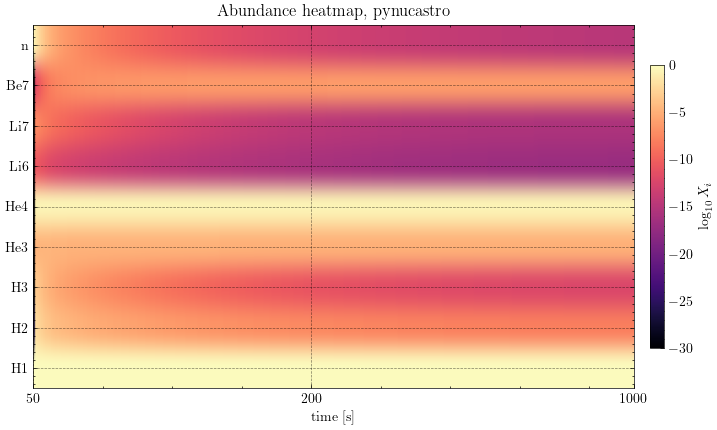

In [5]:
# Heatmap estático de log10(X_i) frente a tiempo y especie.

def abundance_cols(df):
    cols = [c for c in df.columns if c.startswith("X_")]
    preferred = ["X_H1", "X_H2", "X_H3", "X_He3", "X_He4", "X_Li6", "X_Li7", "X_Be7"]
    ordered = [c for c in preferred if c in cols]
    ordered += [c for c in cols if c not in ordered]
    return ordered

def plot_heatmap(df, outname, title):
    cols = abundance_cols(df)
    # Re-muestreo en una malla logarítmica común para que el mapa sea legible.
    t_grid = np.geomspace(df["t_s"].min(), df["t_s"].max(), 300)
    data = []
    for col in cols:
        y = np.interp(t_grid, df["t_s"], df[col])
        data.append(np.log10(np.clip(y, 1e-30, None)))
    data = np.array(data)
    fig, ax = plt.subplots(figsize=(7.4, 4.5))
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="magma",
                   extent=[np.log10(t_grid.min()), np.log10(t_grid.max()), -0.5, len(cols)-0.5],
                   vmin=-30, vmax=0)
    ax.set_yticks(np.arange(len(cols)))
    ax.set_yticklabels([c[2:] for c in cols])
    xticks = np.array([10, 50, 200, 1000, 1e4, 1e5])
    xticks = xticks[(xticks >= t_grid.min()) & (xticks <= t_grid.max())]
    ax.set_xticks(np.log10(xticks))
    ax.set_xticklabels([f"{x:g}" for x in xticks])
    ax.set_xlabel("time [s]")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax, shrink=0.78, fraction=0.045, pad=0.025)
    cb.set_label(r"$\log_{10} X_i$")
    fig.tight_layout()
    fig.savefig(FIG_DIR / outname)
    plt.show()

plot_heatmap(model, "fig_heatmap_abundances_t0_50s.pdf", r"Abundance heatmap, pynucastro")

In [6]:
# GIF: evolución de las abundancias como barras logarítmicas.
# Puede tardar unos segundos. Si Pillow no está instalado: pip install pillow

def make_abundance_gif(df, outname, title, nframes=30):
    cols = abundance_cols(df)
    names = [c[2:] for c in cols]
    frame_times = np.geomspace(df["t_s"].min(), df["t_s"].max(), nframes)
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    x = np.arange(len(cols))
    initial = np.ones(len(cols))*1e-30
    bars = ax.bar(x, initial)
    ax.set_yscale("log")
    ax.set_ylim(1e-30, 1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel(r"mass fraction $X_i$")
    title_obj = ax.set_title(title)

    def update(frame):
        t = frame_times[frame]
        vals = []
        for col in cols:
            vals.append(max(np.interp(t, df["t_s"], df[col]), 1e-30))
        for b, v in zip(bars, vals):
            b.set_height(v)
        title_obj.set_text(f"{title} — t = {t:.2e} s")
        return list(bars) + [title_obj]

    anim = FuncAnimation(fig, update, frames=nframes, interval=100, blit=False)
    anim.save(GIF_DIR / outname, writer=PillowWriter(fps=10))
    plt.close(fig)

make_abundance_gif(model, "gif_abundances_t0_50s.gif", "BBN abundances, pynucastro")
print("GIFs guardados en", GIF_DIR)

GIFs guardados en /home/daniel/GitHub/BNN_simulation/main/gifs
